<a href="https://colab.research.google.com/github/kevinquiosc-rgb/Projectos_Kevin/blob/main/Power_BI_Tiempo_de_Vida_de_Cliente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reporte BI para el analisis del tiempo de vidas de clientes en una empresa SaaS

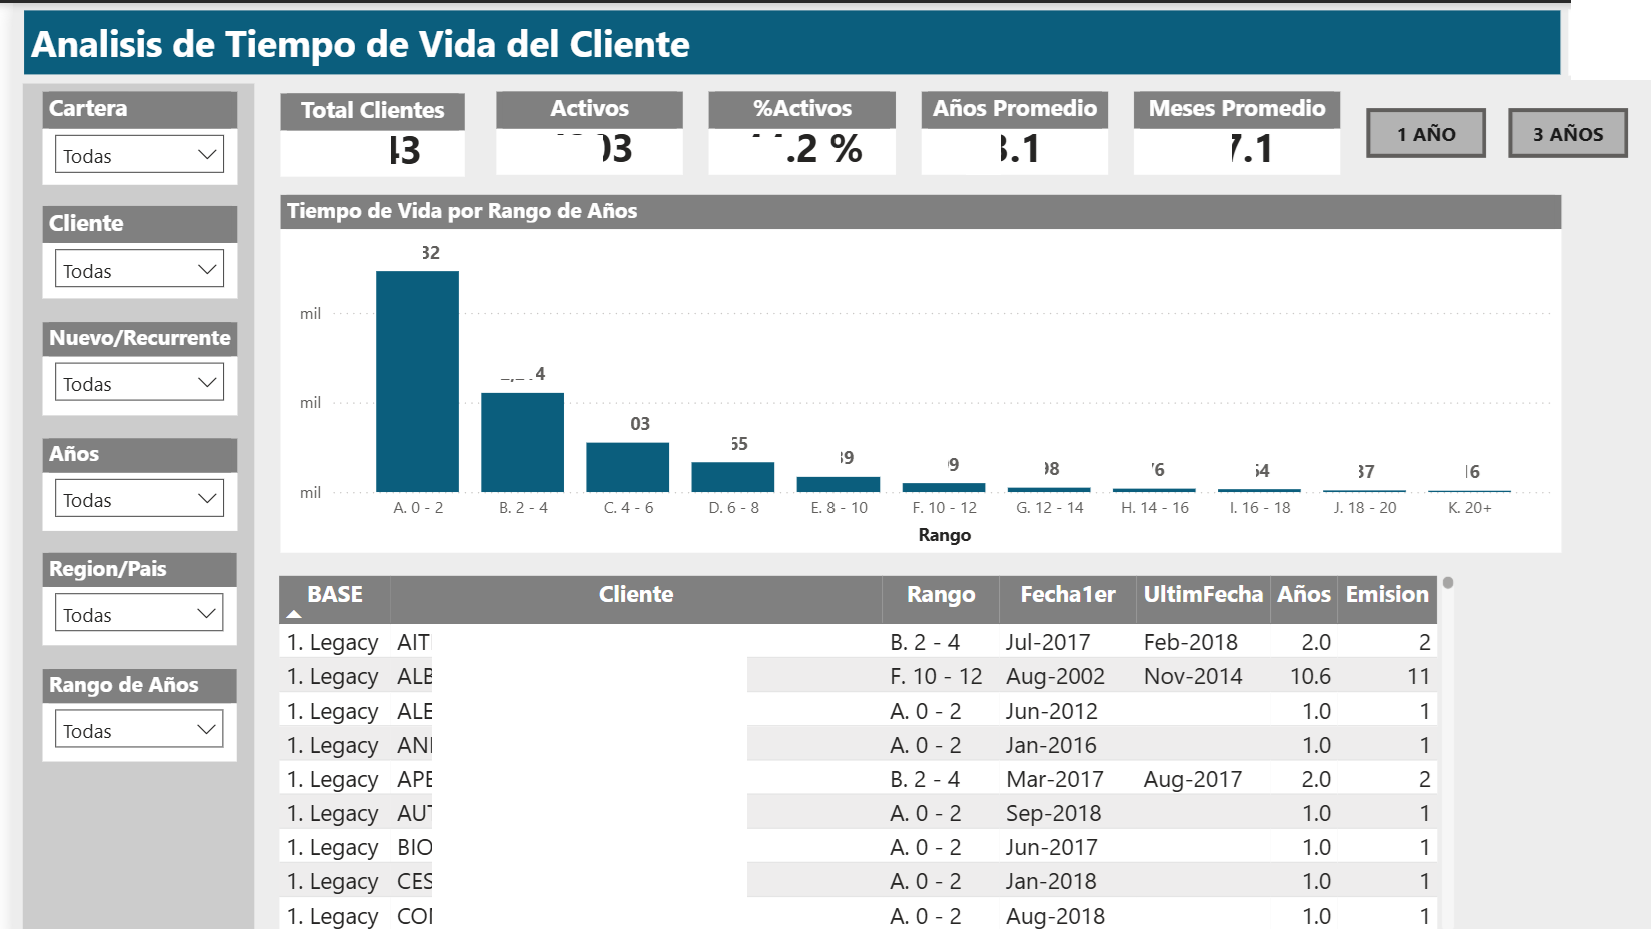

Fuente: Data censurada de una empresa b2b


El siguiente reporte fue realizado para entender el tiempo de vida promedio en el que se ubican los clientes de una empresa de SaaS con este reporte permitió tener visibilidad desde 2 enfoques:

- Ventas: Permite evidenciar la utilidad del servicio para los clientes nuevos lo que denota una buena explicacion del servicio al momento de la venta.
- Renovacion: Permite evidenciar la longevidad promedio para poder establecer estrategias para renovar de forma mas duradera.

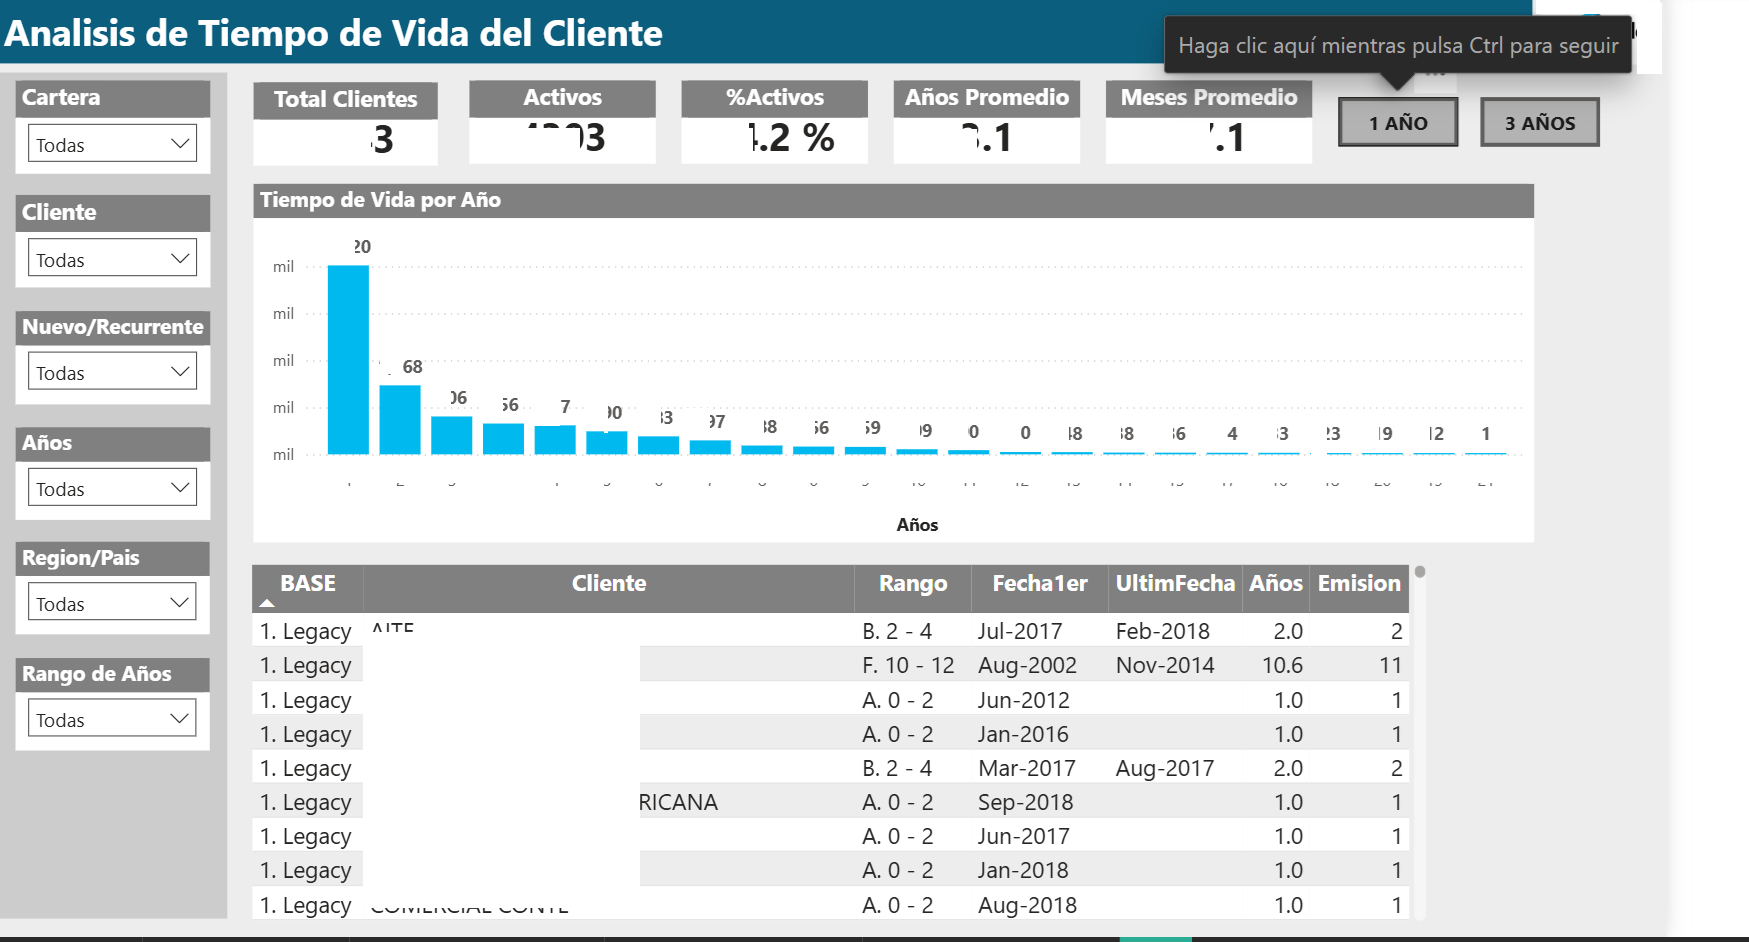

Fuente: Data censurada de una empresa b2b


Con el boton 1 AÑO se puede modificar el grafico central para tener la distribucion de los años de vida del cliente de forma unitaria.

# Proceso ETL

select '1. Legacy' as BASE ,
cliente.IdCliente ,cliente.cliente,
FechaFactura as FechaEmision,
Vigencia, CAST( Meses as float ) as Meses,historico.CodPais,[Plan] -- tipoplan
from historico , Cliente where Historico.IdUsuarioLegacy = cliente.IdUsuarioLegacy

union

 --TABLA FACTURA despues del CRM
select '2. CRM' as BASE,
v.idcliente  ,v.Cliente, f.FechaEmision,
case when c.codvigencia = 'SEM' then 'Semestral'
	when c.codvigencia = 'ANU'  then 'Anual'
	when c.codvigencia = 'TRI'  then 'Trimestral' else c.codvigencia
	end as vigencia,
case when c.codvigencia = 'SEM' then 6
	when c.codvigencia = 'ANU' then 12
	when c.codvigencia = 'TRI' then 3 else c.codvigencia
	end as Meses,
v.codpais, p.[Plan]
 FROM Factura f inner join ordenpedido o
 on f.nroordenpedido = o.nroordenpedido
 inner join Cotizacion c on o.nrocotizacion = c.nrocotizacion
 inner join V_Cliente v on f.idcliente = v.idcliente
 inner join [Plan] p on v.[Plan] = p.[Plan]
 where f.CodEstado='EMT' and f.CodTipoDoc = '01'

Se unieron 2 bases de datos una diseñada de forma empirica y la 2da la proveniente de un CRM mas moderno en donde la data se encontraba de forma mas ordenada por lo que se buscaron campos que tuviesen en comun sin embargo se especifica en la bbdd que base es LEGACY y cual es CRM.

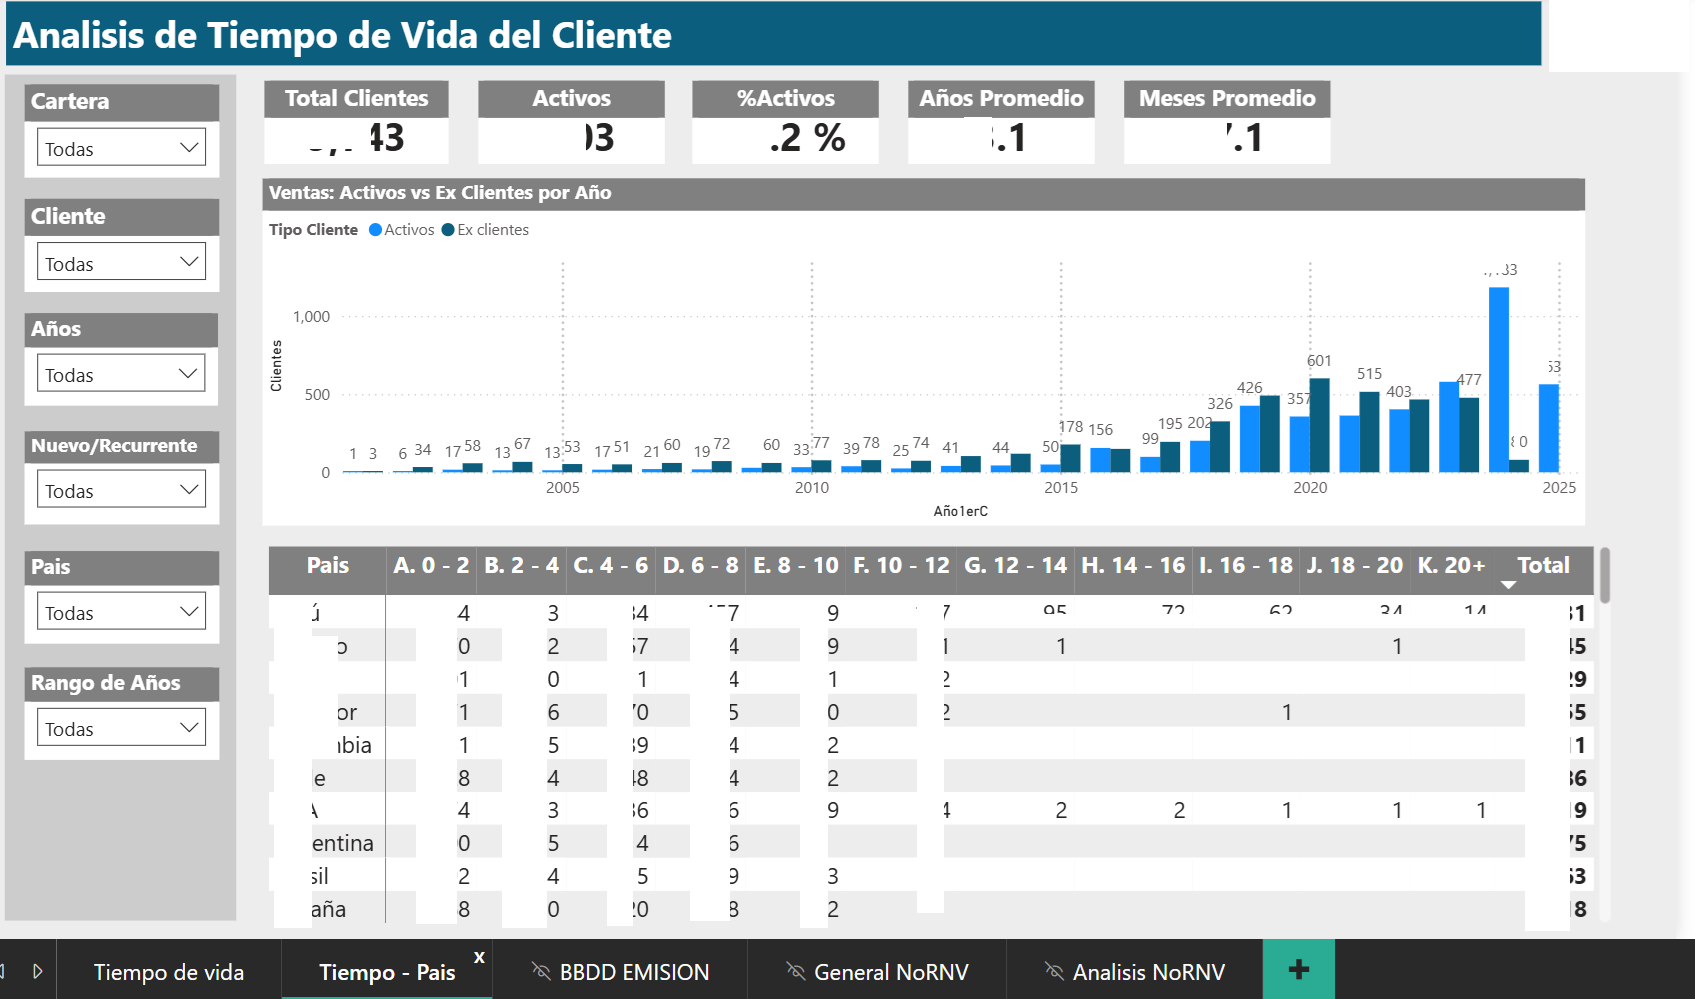

Finalmente en otra hoja se tiene divididos los años de un cliente de acuerdo al pais al que pertenecen y por rango de edad.

Ademas se cuenta con los siguientes filtros:
+ Cartera (LEGACY O CRM)
+ CLIENTE (EX CLIENTE O ACTIVO)
+ AÑOS (FOCO EN UN CLIENTE CON CIERTA EDAD)
+ NUEVO RECURRENTE ( SI ES UN CLIENTE DE PRIMER AÑO O CON VARIAS RENOVACIONES)
+ PAIS
+ RANGO DE AÑOS